# Análise Incremental de Grafos Esparsos

Este notebook realiza testes incrementais nos grafos esparsos reais (10k vértices),
seguindo a mesma estrutura do trabalho:
- **Parte 1**: Algoritmo de Dijkstra
- **Parte 2**: Heurística Gulosa
- **Comparação**: Análise comparativa

---

In [89]:
# Imports necessários
from typing import Dict, List, Tuple
from collections import deque
from math import inf
import heapq
import os
import matplotlib.pyplot as plt
import numpy as np

## Configurações Iniciais

In [90]:
# Configurações
ORIGEM = 0
SEED = 42

# Caminhos dos arquivos
caminho_10k = r'D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\10000.txt'
caminho_1m  = r'D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\1000000.txt'

# Instância ativa: aceite '10k' ou '1m' (case-insensitive)
INSTANCIA = '10k'  # mude para '1m' para usar a instância de 1 milhão

# Modo de geração de tamanhos:
# - 'incremental': gera de INICIO a FIM com passo configurável (ex.: de 100 em 100)
# - 'amostras': gera N_AMOSTRAS valores entre N_MIN e V_MAX (escala 'lin' ou 'log')
MODO_TAMANHOS = 'incremental'   # 'incremental' ou 'amostras'

# Configurações do modo 'incremental'
INICIO_INCREMENTAL = None    # se None, usa N_MIN da instância
FIM_INCREMENTAL    = None    # se None, usa V_MAX da instância
PASSO_INCREMENTAL  = 10     # ex.: 100 para "de 100 em 100"

# Configurações do modo 'amostras'
N_AMOSTRAS = 50              # quantidade de amostras quando MODO_TAMANHOS='amostras'
ESCALA_AMOSTRAS = 'lin'      # 'lin' ou 'log'

# Seleção de caminho e parâmetros por instância
inst_norm = INSTANCIA.lower()
if inst_norm == '10k':
    caminho = caminho_10k
    V_MAX = 10_000
    N_MIN = 10
    inst_suf = '10k'
elif inst_norm == '1m':
    caminho = caminho_1m
    V_MAX = 1_000_000
    N_MIN = 1_000  # ponto inicial mais razoável para reduzir custo
    inst_suf = '1m'
else:
    print("⚠️ INSTANCIA inválida; usando '10k' por padrão.")
    caminho = caminho_10k
    V_MAX = 10_000
    N_MIN = 10
    inst_suf = '10k'

# Construção da lista de tamanhos conforme o modo
if MODO_TAMANHOS == 'incremental':
    inicio = INICIO_INCREMENTAL if INICIO_INCREMENTAL is not None else N_MIN
    fim    = FIM_INCREMENTAL    if FIM_INCREMENTAL    is not None else V_MAX
    inicio = max(2, int(inicio))
    fim    = int(fim)
    passo  = max(1, int(PASSO_INCREMENTAL))
    tamanhos = list(range(inicio, fim + 1, passo))
    # Garante inclusão do FIM, se não múltiplo exato do passo
    if tamanhos and tamanhos[-1] != fim and fim > tamanhos[-1]:
        tamanhos.append(fim)
else:  # 'amostras'
    N_MIN = max(2, N_MIN)
    if ESCALA_AMOSTRAS == 'log':
        xs = np.logspace(np.log10(N_MIN), np.log10(V_MAX), num=max(2, N_AMOSTRAS))
    else:  # 'lin'
        xs = np.linspace(N_MIN, V_MAX, num=max(2, N_AMOSTRAS))
    tamanhos = sorted({int(round(x)) for x in xs if x >= N_MIN and x <= V_MAX})

print('Verificando arquivos:')
print(f"  10k: {'✓ Encontrado' if os.path.exists(caminho_10k) else '✗ Não encontrado'}")
print(f"  1M : {'✓ Encontrado' if os.path.exists(caminho_1m) else '✗ Não encontrado'}")

print(f"\nInstância ativa: {INSTANCIA} -> {caminho}")
if MODO_TAMANHOS == 'incremental':
    print(f"Modo tamanhos: incremental (início={inicio:,}, fim={fim:,}, passo={passo:,})")
else:
    print(f"Modo tamanhos: amostras ({ESCALA_AMOSTRAS})")
print(f'Total de testes: {len(tamanhos)}')
print(f'Primeiros: {tamanhos[:10]}')
print(f'Últimos: {tamanhos[-10:]}')

Verificando arquivos:
  10k: ✓ Encontrado
  1M : ✗ Não encontrado

Instância ativa: 10k -> D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\10000.txt
Modo tamanhos: incremental (início=10, fim=10,000, passo=10)
Total de testes: 1000
Primeiros: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
Últimos: [9910, 9920, 9930, 9940, 9950, 9960, 9970, 9980, 9990, 10000]


## Funções Auxiliares

In [91]:
def carregar_grafo_ewd(caminho: str, max_vertices: int = None):
    """Carrega grafo em formato EWD, limitado a max_vertices."""
    with open(caminho, 'r', encoding='utf-8') as f:
        V = int(f.readline().strip())
        E = int(f.readline().strip())
        
        if max_vertices is not None:
            V = min(V, max_vertices)
        
        adj = {i: [] for i in range(V)}
        num_arestas = 0
        
        for _ in range(E):
            linha = f.readline().strip()
            if not linha:
                break
            u, v, peso = linha.split()[:3]
            u, v = int(u), int(v)
            
            if u < V and v < V:
                adj[u].append((v, float(peso)))
                num_arestas += 1
    
    return adj, num_arestas

print('✓ Função de carregamento criada')

✓ Função de carregamento criada


---
# PARTE 1 — ALGORITMO DE DIJKSTRA
---

## I. Implementação do Algoritmo de Dijkstra

In [92]:
def dijkstra(adj: Dict[int, List[Tuple[int, float]]], origem: int = 0):
    """Algoritmo de Dijkstra com heap binário."""
    n = len(adj)
    dist = [inf] * n
    parent = [-1] * n
    dist[origem] = 0
    
    heap = [(0, origem)]
    comparacoes = 0
    
    while heap:
        d, u = heapq.heappop(heap)
        
        if d > dist[u]:
            continue
        
        for v, peso in adj[u]:
            comparacoes += 1
            nova_dist = dist[u] + peso
            
            if nova_dist < dist[v]:
                dist[v] = nova_dist
                parent[v] = u
                heapq.heappush(heap, (nova_dist, v))
    
    return dist, parent, comparacoes

print('✓ Dijkstra implementado')

✓ Dijkstra implementado


## II. Testes Incrementais com Dijkstra

In [93]:
# Executar testes incrementais com Dijkstra
resultados_dijkstra = {
    'tamanhos': [],
    'arestas': [],
    'comparacoes': [],
    'alcancados': []
}

if os.path.exists(caminho):
    print('='*70)
    print(f'PARTE 1: TESTES INCREMENTAIS - DIJKSTRA ({INSTANCIA})')
    print('='*70)
    
    for i, tam in enumerate(tamanhos, 1):
        # Carregar subgrafo
        grafo, num_arestas = carregar_grafo_ewd(caminho, max_vertices=tam)
        
        # Executar Dijkstra
        dist, parent, comp = dijkstra(grafo, origem=ORIGEM)
        alcancados = sum(1 for d in dist if d != inf)
        
        # Armazenar resultados
        resultados_dijkstra['tamanhos'].append(tam)
        resultados_dijkstra['arestas'].append(num_arestas)
        resultados_dijkstra['comparacoes'].append(comp)
        resultados_dijkstra['alcancados'].append(alcancados)
        
        # Mostrar progresso a cada 20 testes
        if i % 20 == 0 or i == len(tamanhos):
            print(f'  [{i}/{len(tamanhos)}] n={tam:,}: {comp:,} comp, {alcancados:,} vértices')
    
    print('\n✓ Testes Dijkstra concluídos!')
else:
    print('✗ Arquivo não encontrado!')

PARTE 1: TESTES INCREMENTAIS - DIJKSTRA (10k)
  [20/1000] n=200: 0 comp, 1 vértices
  [20/1000] n=200: 0 comp, 1 vértices
  [40/1000] n=400: 0 comp, 1 vértices
  [40/1000] n=400: 0 comp, 1 vértices
  [60/1000] n=600: 10 comp, 5 vértices
  [60/1000] n=600: 10 comp, 5 vértices
  [80/1000] n=800: 14 comp, 6 vértices
  [80/1000] n=800: 14 comp, 6 vértices
  [100/1000] n=1,000: 20 comp, 7 vértices
  [100/1000] n=1,000: 20 comp, 7 vértices
  [120/1000] n=1,200: 30 comp, 8 vértices
  [120/1000] n=1,200: 30 comp, 8 vértices
  [140/1000] n=1,400: 30 comp, 8 vértices
  [140/1000] n=1,400: 30 comp, 8 vértices
  [160/1000] n=1,600: 102 comp, 27 vértices
  [160/1000] n=1,600: 102 comp, 27 vértices
  [180/1000] n=1,800: 138 comp, 41 vértices
  [180/1000] n=1,800: 138 comp, 41 vértices
  [200/1000] n=2,000: 148 comp, 43 vértices
  [200/1000] n=2,000: 148 comp, 43 vértices
  [220/1000] n=2,200: 154 comp, 45 vértices
  [220/1000] n=2,200: 154 comp, 45 vértices
  [240/1000] n=2,400: 180 comp, 51 vértice

## III. Salvar Resultados - Dijkstra

In [94]:
if resultados_dijkstra['tamanhos']:
    os.makedirs('resultados/analise_esparsos', exist_ok=True)
    
    with open(f'resultados/analise_esparsos/parte1_dijkstra_{inst_suf}.txt', 'w', encoding='utf-8') as f:
        f.write(f'PARTE 1 — ALGORITMO DE DIJKSTRA (Grafos Esparsos) — Instância {INSTANCIA}\n')
        f.write('='*80 + '\n\n')
        f.write(f'{"Vértices":<12}{"Arestas":<12}{"Comparações":<16}{"Alcançados":<14}{"% Alcançados":<14}\n')
        f.write('-'*80 + '\n')
        
        for i in range(len(resultados_dijkstra['tamanhos'])):
            tam = resultados_dijkstra['tamanhos'][i]
            arestas = resultados_dijkstra['arestas'][i]
            comp = resultados_dijkstra['comparacoes'][i]
            alc = resultados_dijkstra['alcancados'][i]
            perc = (alc / tam * 100) if tam > 0 else 0
            
            f.write(f'{tam:<12,}{arestas:<12,}{comp:<16,}{alc:<14,}{perc:<14.2f}%\n')
    
    print(f'✓ Resultados salvos: resultados/analise_esparsos/parte1_dijkstra_{inst_suf}.txt')

✓ Resultados salvos: resultados/analise_esparsos/parte1_dijkstra_10k.txt


## IV. Gráficos - Dijkstra

✓ Gráfico salvo: resultados/analise_esparsos/img/parte1_dijkstra_comp_10k.png


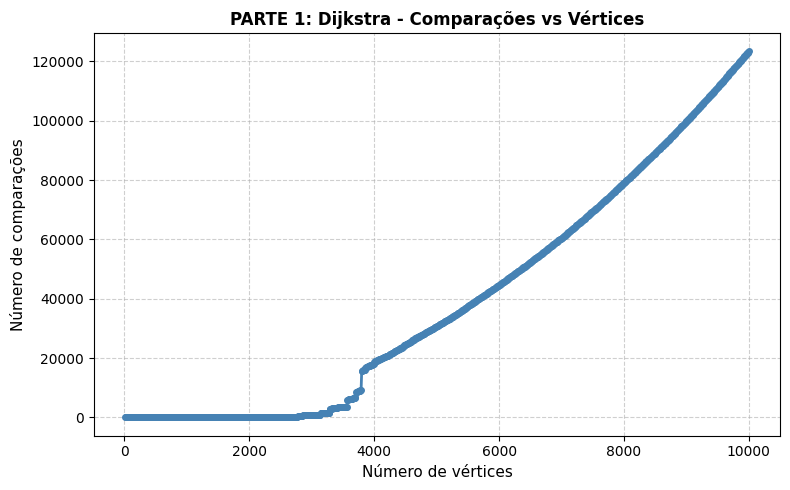

✓ Gráfico salvo: resultados/analise_esparsos/img/parte1_dijkstra_alcancados_10k.png


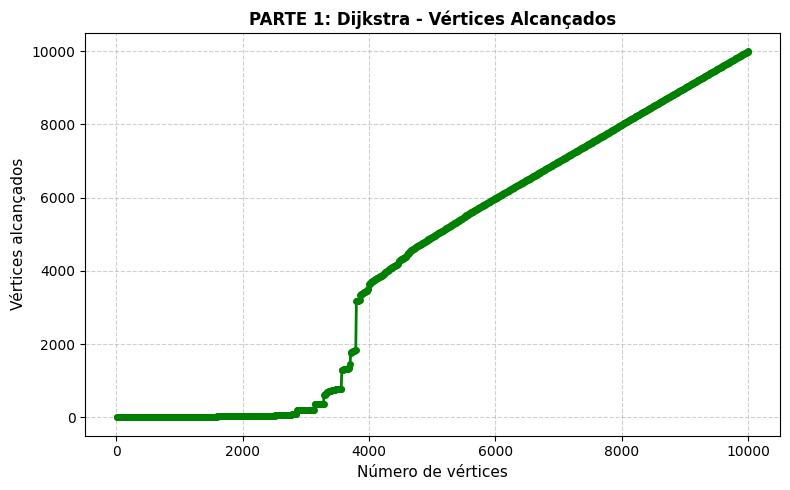

In [95]:
if resultados_dijkstra['tamanhos']:
    os.makedirs('resultados/analise_esparsos/img', exist_ok=True)

    # Gráfico 1: Comparações vs Vértices (figura separada)
    plt.figure(figsize=(8, 5))
    plt.plot(resultados_dijkstra['tamanhos'], resultados_dijkstra['comparacoes'],
             marker='o', linewidth=2, markersize=4, color='steelblue')
    plt.xlabel('Número de vértices', fontsize=11)
    plt.ylabel('Número de comparações', fontsize=11)
    plt.title('PARTE 1: Dijkstra - Comparações vs Vértices', fontsize=12, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/parte1_dijkstra_comp_{inst_suf}.png', dpi=150)
    print(f'✓ Gráfico salvo: resultados/analise_esparsos/img/parte1_dijkstra_comp_{inst_suf}.png')
    plt.show()

    # Gráfico 2: Vértices Alcançados (figura separada)
    plt.figure(figsize=(8, 5))
    plt.plot(resultados_dijkstra['tamanhos'], resultados_dijkstra['alcancados'],
             marker='o', linewidth=2, markersize=4, color='green')
    plt.xlabel('Número de vértices', fontsize=11)
    plt.ylabel('Vértices alcançados', fontsize=11)
    plt.title('PARTE 1: Dijkstra - Vértices Alcançados', fontsize=12, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/parte1_dijkstra_alcancados_{inst_suf}.png', dpi=150)
    print(f'✓ Gráfico salvo: resultados/analise_esparsos/img/parte1_dijkstra_alcancados_{inst_suf}.png')
    plt.show()
else:
    print('✗ Resultados Dijkstra indisponíveis para gráficos')

---
# PARTE 2 — HEURÍSTICA GULOSA
---

## I. Implementação da Heurística Gulosa

In [96]:
def heuristica_gulosa(adj: Dict[int, List[Tuple[int, float]]], origem: int = 0):
    """Heurística Gulosa - escolhe sempre a aresta de menor peso."""
    n = len(adj)
    dist = [inf] * n
    parent = [-1] * n
    dist[origem] = 0
    
    visited = {origem}
    fila = deque([origem])
    comparacoes = 0
    
    while fila:
        u = fila.popleft()
        melhor_v = None
        melhor_custo = inf
        
        for v, peso in adj[u]:
            comparacoes += 1
            if v in visited:
                continue
            custo = dist[u] + peso
            if custo < dist[v] and custo < melhor_custo:
                melhor_custo = custo
                melhor_v = v
        
        if melhor_v is not None:
            dist[melhor_v] = melhor_custo
            parent[melhor_v] = u
            visited.add(melhor_v)
            fila.append(melhor_v)
    
    return dist, parent, comparacoes

print('✓ Heurística Gulosa implementada')

✓ Heurística Gulosa implementada


## II. Testes Incrementais com Heurística Gulosa

In [97]:
# Executar testes incrementais com Heurística Gulosa
resultados_gulosa = {
    'tamanhos': [],
    'arestas': [],
    'comparacoes': [],
    'alcancados': []
}

if os.path.exists(caminho):
    print('='*70)
    print(f'PARTE 2: TESTES INCREMENTAIS - HEURÍSTICA GULOSA ({INSTANCIA})')
    print('='*70)
    
    for i, tam in enumerate(tamanhos, 1):
        # Carregar subgrafo
        grafo, num_arestas = carregar_grafo_ewd(caminho, max_vertices=tam)
        
        # Executar Heurística Gulosa
        dist, parent, comp = heuristica_gulosa(grafo, origem=ORIGEM)
        alcancados = sum(1 for d in dist if d != inf)
        
        # Armazenar resultados
        resultados_gulosa['tamanhos'].append(tam)
        resultados_gulosa['arestas'].append(num_arestas)
        resultados_gulosa['comparacoes'].append(comp)
        resultados_gulosa['alcancados'].append(alcancados)
        
        # Mostrar progresso a cada 20 testes
        if i % 20 == 0 or i == len(tamanhos):
            print(f'  [{i}/{len(tamanhos)}] n={tam:,}: {comp:,} comp, {alcancados:,} vértices')
    
    print('\n✓ Testes Gulosa concluídos!')
else:
    print('✗ Arquivo não encontrado!')

PARTE 2: TESTES INCREMENTAIS - HEURÍSTICA GULOSA (10k)
  [20/1000] n=200: 0 comp, 1 vértices
  [20/1000] n=200: 0 comp, 1 vértices
  [40/1000] n=400: 0 comp, 1 vértices
  [40/1000] n=400: 0 comp, 1 vértices
  [60/1000] n=600: 10 comp, 5 vértices
  [60/1000] n=600: 10 comp, 5 vértices
  [80/1000] n=800: 14 comp, 6 vértices
  [80/1000] n=800: 14 comp, 6 vértices
  [100/1000] n=1,000: 20 comp, 7 vértices
  [100/1000] n=1,000: 20 comp, 7 vértices
  [120/1000] n=1,200: 30 comp, 8 vértices
  [120/1000] n=1,200: 30 comp, 8 vértices
  [140/1000] n=1,400: 30 comp, 8 vértices
  [140/1000] n=1,400: 30 comp, 8 vértices
  [160/1000] n=1,600: 68 comp, 14 vértices
  [160/1000] n=1,600: 68 comp, 14 vértices
  [180/1000] n=1,800: 68 comp, 14 vértices
  [180/1000] n=1,800: 68 comp, 14 vértices
  [200/1000] n=2,000: 52 comp, 10 vértices
  [200/1000] n=2,000: 52 comp, 10 vértices
  [220/1000] n=2,200: 52 comp, 10 vértices
  [220/1000] n=2,200: 52 comp, 10 vértices
  [240/1000] n=2,400: 59 comp, 11 vértice

## III. Salvar Resultados - Heurística Gulosa

In [98]:
if resultados_gulosa['tamanhos']:
    with open(f'resultados/analise_esparsos/parte2_gulosa_{inst_suf}.txt', 'w', encoding='utf-8') as f:
        f.write(f'PARTE 2 — HEURÍSTICA GULOSA (Grafos Esparsos) — Instância {INSTANCIA}\n')
        f.write('='*80 + '\n\n')
        f.write(f'{"Vértices":<12}{"Arestas":<12}{"Comparações":<16}{"Alcançados":<14}{"% Alcançados":<14}\n')
        f.write('-'*80 + '\n')
        
        for i in range(len(resultados_gulosa['tamanhos'])):
            tam = resultados_gulosa['tamanhos'][i]
            arestas = resultados_gulosa['arestas'][i]
            comp = resultados_gulosa['comparacoes'][i]
            alc = resultados_gulosa['alcancados'][i]
            perc = (alc / tam * 100) if tam > 0 else 0
            
            f.write(f'{tam:<12,}{arestas:<12,}{comp:<16,}{alc:<14,}{perc:<14.2f}%\n')
    
    print(f'✓ Resultados salvos: resultados/analise_esparsos/parte2_gulosa_{inst_suf}.txt')

✓ Resultados salvos: resultados/analise_esparsos/parte2_gulosa_10k.txt


## IV. Gráficos - Heurística Gulosa

✓ Gráfico salvo: resultados/analise_esparsos/img/parte2_gulosa_comp_10k.png


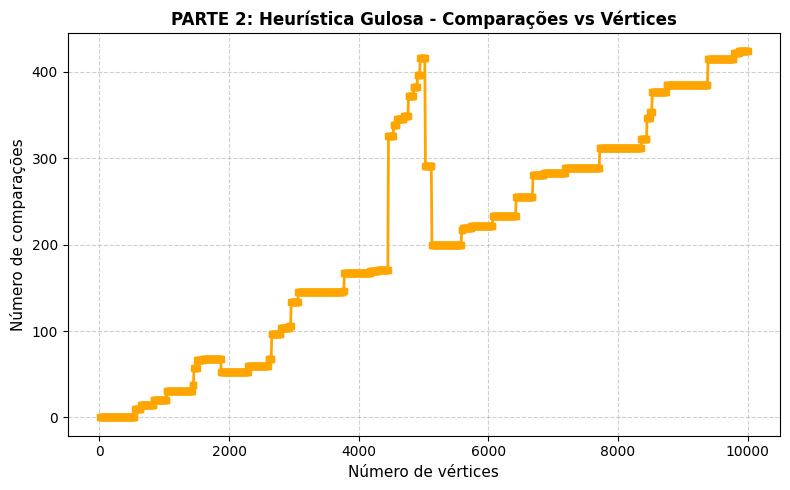

✓ Gráfico salvo: resultados/analise_esparsos/img/parte2_gulosa_alcancados_10k.png


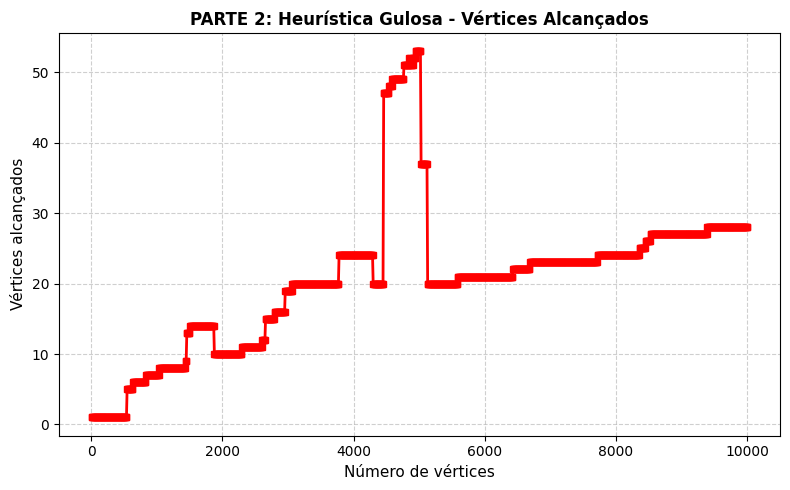

In [99]:
if resultados_gulosa['tamanhos']:
    os.makedirs('resultados/analise_esparsos/img', exist_ok=True)

    # Gráfico 1: Comparações vs Vértices (figura separada)
    plt.figure(figsize=(8, 5))
    plt.plot(resultados_gulosa['tamanhos'], resultados_gulosa['comparacoes'],
             marker='s', linewidth=2, markersize=4, color='orange')
    plt.xlabel('Número de vértices', fontsize=11)
    plt.ylabel('Número de comparações', fontsize=11)
    plt.title('PARTE 2: Heurística Gulosa - Comparações vs Vértices', fontsize=12, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/parte2_gulosa_comp_{inst_suf}.png', dpi=150)
    print(f'✓ Gráfico salvo: resultados/analise_esparsos/img/parte2_gulosa_comp_{inst_suf}.png')
    plt.show()

    # Gráfico 2: Vértices Alcançados (figura separada)
    plt.figure(figsize=(8, 5))
    plt.plot(resultados_gulosa['tamanhos'], resultados_gulosa['alcancados'],
             marker='s', linewidth=2, markersize=4, color='red')
    plt.xlabel('Número de vértices', fontsize=11)
    plt.ylabel('Vértices alcançados', fontsize=11)
    plt.title('PARTE 2: Heurística Gulosa - Vértices Alcançados', fontsize=12, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/parte2_gulosa_alcancados_{inst_suf}.png', dpi=150)
    print(f'✓ Gráfico salvo: resultados/analise_esparsos/img/parte2_gulosa_alcancados_{inst_suf}.png')
    plt.show()
else:
    print('✗ Resultados Gulosa indisponíveis para gráficos')

---
# COMPARAÇÃO ENTRE OS ALGORITMOS
---

## I. Tabela Comparativa

In [100]:
if resultados_dijkstra['tamanhos'] and resultados_gulosa['tamanhos']:
    with open(f'resultados/analise_esparsos/comparacao_{inst_suf}.txt', 'w', encoding='utf-8') as f:
        f.write(f'COMPARAÇÃO: DIJKSTRA vs HEURÍSTICA GULOSA (Grafos Esparsos) — Instância {INSTANCIA}\n')
        f.write('='*120 + '\n\n')
        f.write(f'{"Vértices":<10}{"Arestas":<10}{"Dij Comp":<14}{"Dij Alc":<12}{"Gul Comp":<14}{"Gul Alc":<12}{"Red Comp%":<12}{"Perda Alc%":<14}\n')
        f.write('-'*120 + '\n')
        
        for i in range(len(resultados_dijkstra['tamanhos'])):
            tam = resultados_dijkstra['tamanhos'][i]
            arestas = resultados_dijkstra['arestas'][i]
            
            d_comp = resultados_dijkstra['comparacoes'][i]
            d_alc = resultados_dijkstra['alcancados'][i]
            
            g_comp = resultados_gulosa['comparacoes'][i]
            g_alc = resultados_gulosa['alcancados'][i]
            
            red_comp = (1 - g_comp/d_comp)*100 if d_comp > 0 else 0
            perda_alc = (1 - g_alc/d_alc)*100 if d_alc > 0 else 0
            
            f.write(f'{tam:<10,}{arestas:<10,}{d_comp:<14,}{d_alc:<12,}{g_comp:<14,}{g_alc:<12,}{red_comp:<12.2f}%{perda_alc:<14.2f}%\n')
    
    print(f'✓ Comparação salva: resultados/analise_esparsos/comparacao_{inst_suf}.txt')

✓ Comparação salva: resultados/analise_esparsos/comparacao_10k.txt


## II. Gráficos Comparativos

✓ Gráfico salvo: resultados/analise_esparsos/img/comparacao_comp_10k.png


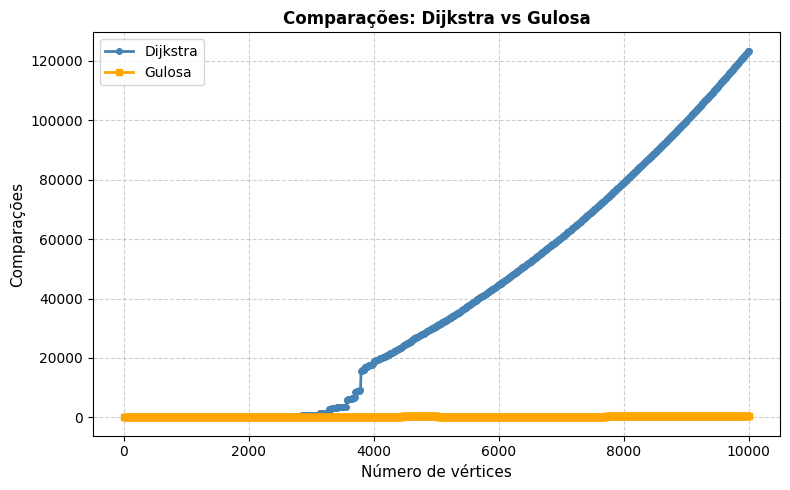

✓ Gráfico salvo: resultados/analise_esparsos/img/comparacao_comp_log_10k.png


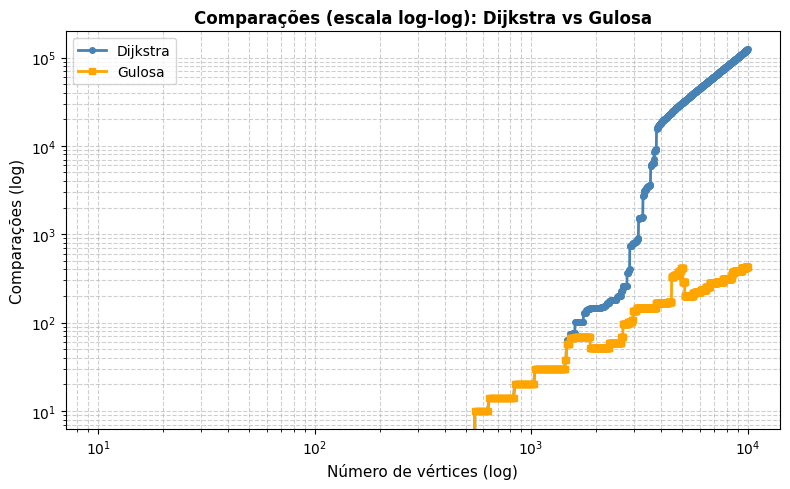

✓ Gráfico salvo: resultados/analise_esparsos/img/comparacao_alcancados_10k.png


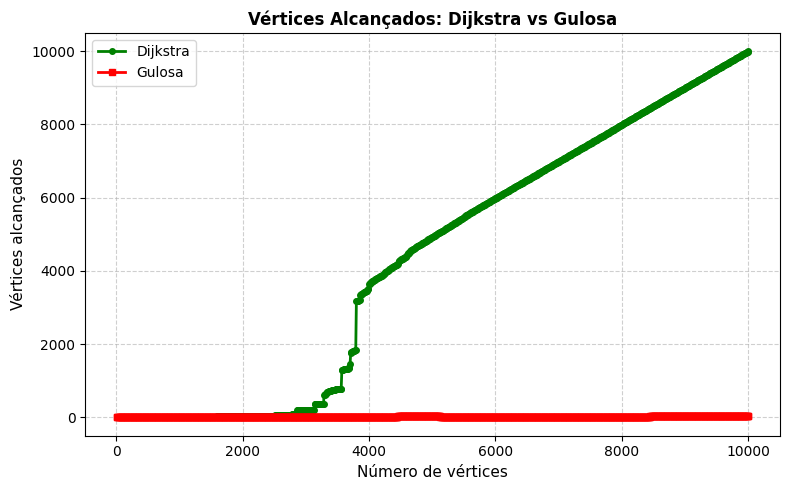

✓ Gráfico salvo: resultados/analise_esparsos/img/reducao_comparacoes_10k.png


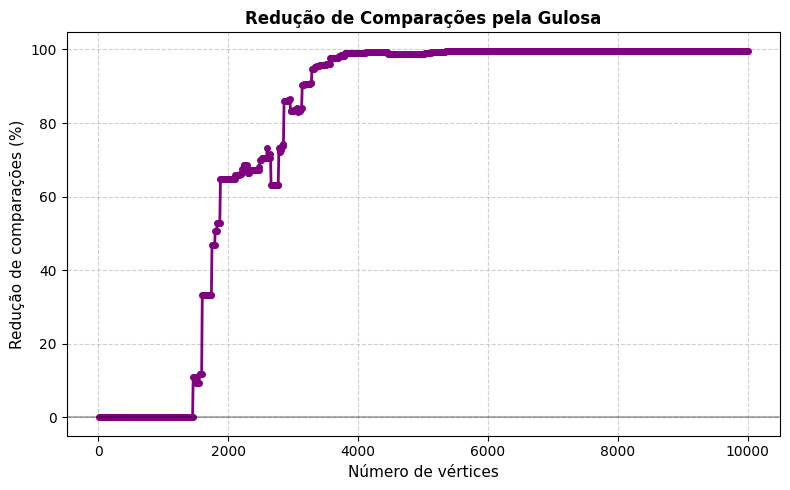

✓ Gráfico salvo: resultados/analise_esparsos/img/taxa_alcance_gulosa_10k.png


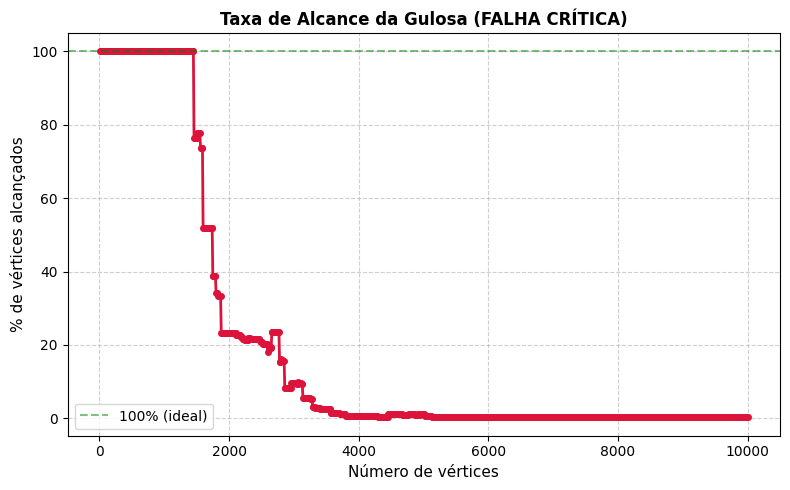

In [101]:
if resultados_dijkstra['tamanhos'] and resultados_gulosa['tamanhos']:
    os.makedirs('resultados/analise_esparsos/img', exist_ok=True)

    # 1) Comparações: Dijkstra vs Gulosa (linear)
    plt.figure(figsize=(8, 5))
    plt.plot(resultados_dijkstra['tamanhos'], resultados_dijkstra['comparacoes'],
             marker='o', linewidth=2, markersize=4, color='steelblue', label='Dijkstra')
    plt.plot(resultados_gulosa['tamanhos'], resultados_gulosa['comparacoes'],
             marker='s', linewidth=2, markersize=4, color='orange', label='Gulosa')
    plt.xlabel('Número de vértices', fontsize=11)
    plt.ylabel('Comparações', fontsize=11)
    plt.title('Comparações: Dijkstra vs Gulosa', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/comparacao_comp_{inst_suf}.png', dpi=150)
    print(f'✓ Gráfico salvo: resultados/analise_esparsos/img/comparacao_comp_{inst_suf}.png')
    plt.show()

    # 1b) Comparações: Dijkstra vs Gulosa (escala log-log)
    plt.figure(figsize=(8, 5))
    plt.plot(resultados_dijkstra['tamanhos'], resultados_dijkstra['comparacoes'],
             marker='o', linewidth=2, markersize=4, color='steelblue', label='Dijkstra')
    plt.plot(resultados_gulosa['tamanhos'], resultados_gulosa['comparacoes'],
             marker='s', linewidth=2, markersize=4, color='orange', label='Gulosa')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Número de vértices (log)', fontsize=11)
    plt.ylabel('Comparações (log)', fontsize=11)
    plt.title('Comparações (escala log-log): Dijkstra vs Gulosa', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/comparacao_comp_log_{inst_suf}.png', dpi=150)
    print(f'✓ Gráfico salvo: resultados/analise_esparsos/img/comparacao_comp_log_{inst_suf}.png')
    plt.show()

    # 2) Vértices alcançados: Dijkstra vs Gulosa
    plt.figure(figsize=(8, 5))
    plt.plot(resultados_dijkstra['tamanhos'], resultados_dijkstra['alcancados'],
             marker='o', linewidth=2, markersize=4, color='green', label='Dijkstra')
    plt.plot(resultados_gulosa['tamanhos'], resultados_gulosa['alcancados'],
             marker='s', linewidth=2, markersize=4, color='red', label='Gulosa')
    plt.xlabel('Número de vértices', fontsize=11)
    plt.ylabel('Vértices alcançados', fontsize=11)
    plt.title('Vértices Alcançados: Dijkstra vs Gulosa', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/comparacao_alcancados_{inst_suf}.png', dpi=150)
    print(f'✓ Gráfico salvo: resultados/analise_esparsos/img/comparacao_alcancados_{inst_suf}.png')
    plt.show()

    # 3) Redução de comparações (%) da Gulosa em relação ao Dijkstra
    reducao_comp = [(1 - g/d)*100 if d > 0 else 0
                    for g, d in zip(resultados_gulosa['comparacoes'], resultados_dijkstra['comparacoes'])]
    plt.figure(figsize=(8, 5))
    plt.plot(resultados_dijkstra['tamanhos'], reducao_comp,
             marker='o', linewidth=2, markersize=4, color='purple')
    plt.xlabel('Número de vértices', fontsize=11)
    plt.ylabel('Redução de comparações (%)', fontsize=11)
    plt.title('Redução de Comparações pela Gulosa', fontsize=12, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/reducao_comparacoes_{inst_suf}.png', dpi=150)
    print(f'✓ Gráfico salvo: resultados/analise_esparsos/img/reducao_comparacoes_{inst_suf}.png')
    plt.show()

    # 4) Taxa de vértices alcançados (%) da Gulosa em relação ao Dijkstra
    taxa_alcance = [(g/d)*100 if d > 0 else 0
                    for g, d in zip(resultados_gulosa['alcancados'], resultados_dijkstra['alcancados'])]
    plt.figure(figsize=(8, 5))
    plt.plot(resultados_dijkstra['tamanhos'], taxa_alcance,
             marker='o', linewidth=2, markersize=4, color='crimson')
    plt.xlabel('Número de vértices', fontsize=11)
    plt.ylabel('% de vértices alcançados', fontsize=11)
    plt.title('Taxa de Alcance da Gulosa (FALHA CRÍTICA)', fontsize=12, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axhline(y=100, color='green', linestyle='--', alpha=0.5, label='100% (ideal)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'resultados/analise_esparsos/img/taxa_alcance_gulosa_{inst_suf}.png', dpi=150)
    print(f'✓ Gráfico salvo: resultados/analise_esparsos/img/taxa_alcance_gulosa_{inst_suf}.png')
    plt.show()
else:
    print('✗ Resultados insuficientes para gráficos comparativos')

## III. Resumo Estatístico

In [102]:
if resultados_dijkstra['tamanhos'] and resultados_gulosa['tamanhos']:
    print('='*70)
    print('RESUMO ESTATÍSTICO DA COMPARAÇÃO')
    print('='*70)
    
    # Taxa de alcance
    taxa_alcance = [(g/d)*100 if d > 0 else 0 
                   for g, d in zip(resultados_gulosa['alcancados'], resultados_dijkstra['alcancados'])]
    
    print('\n📊 VÉRTICES ALCANÇADOS PELA GULOSA:')
    print(f'  Média: {np.mean(taxa_alcance):.2f}%')
    print(f'  Mínimo: {np.min(taxa_alcance):.2f}%')
    print(f'  Máximo: {np.max(taxa_alcance):.2f}%')
    print(f'  Desvio padrão: {np.std(taxa_alcance):.2f}%')
    
    # Redução de comparações
    reducao_comp = [(1 - g/d)*100 if d > 0 else 0 
                   for g, d in zip(resultados_gulosa['comparacoes'], resultados_dijkstra['comparacoes'])]
    
    print('\n📉 REDUÇÃO DE COMPARAÇÕES:')
    print(f'  Média: {np.mean(reducao_comp):.2f}%')
    print(f'  Mínimo: {np.min(reducao_comp):.2f}%')
    print(f'  Máximo: {np.max(reducao_comp):.2f}%')
    print(f'  Desvio padrão: {np.std(reducao_comp):.2f}%')
    
    print('\n' + '='*70)
    print('⚠️  CONCLUSÃO: A heurística gulosa reduz drasticamente as comparações,')
    print('   mas FALHA em alcançar a maioria dos vértices em grafos esparsos!')
    print('='*70)

RESUMO ESTATÍSTICO DA COMPARAÇÃO

📊 VÉRTICES ALCANÇADOS PELA GULOSA:
  Média: 19.63%
  Mínimo: 0.28%
  Máximo: 100.00%
  Desvio padrão: 35.38%

📉 REDUÇÃO DE COMPARAÇÕES:
  Média: 78.28%
  Mínimo: 0.00%
  Máximo: 99.66%
  Desvio padrão: 36.12%

⚠️  CONCLUSÃO: A heurística gulosa reduz drasticamente as comparações,
   mas FALHA em alcançar a maioria dos vértices em grafos esparsos!
